In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
df = pd.read_csv('data/raw/5-loan_approval_dataset.csv')
df.head(10)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
7,8,2,Graduate,Yes,5700000,15000000,20,382,13200000,5700000,11800000,6000000,Rejected
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
9,10,5,Not Graduate,No,1100000,4300000,10,388,3200000,1400000,3300000,1600000,Rejected


In [3]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')

In [4]:
# Xóa khoảng trắng đầu/cuối ở tên cột
df.columns = df.columns.str.strip()

In [5]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')

# 1. Trình độ học vấn có ảnh hưởng đến số tiền vay hay không?

In [6]:
df['education'].value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [7]:
df['loan_amount'].value_counts()
df['loan_amount']

0       29900000
1       12200000
2       29700000
3       30700000
4       24200000
          ...   
4264     2300000
4265    11300000
4266    23900000
4267    12800000
4268    29700000
Name: loan_amount, Length: 4269, dtype: int64

## 1.1. Kiểm tra tình trạng của biến education

In [8]:
df['education'].unique()

<ArrowStringArray>
[' Graduate', ' Not Graduate']
Length: 2, dtype: str

Xóa khoảng trắng 

In [10]:
df['education'] = df['education'].str.strip()

In [11]:
df['education'].unique()

<ArrowStringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str

Áp dụng kỹ thuật mã hóa dữ liệu: **"Chuyển dữ liệu phân loại định lượng -> định tính"**

=> Áp dụng kỹ thuật Label Encoding cho biến **education** (Graduate/Not Grauduate) -> (1/0)

In [12]:
# Label Encoding
df['education'] = df['education'].map({
    'Graduate': 1,
    'Not Graduate': 0
})

In [14]:
df['education'].info()

<class 'pandas.Series'>
RangeIndex: 4269 entries, 0 to 4268
Series name: education
Non-Null Count  Dtype
--------------  -----
4269 non-null   int64
dtypes: int64(1)
memory usage: 33.5 KB


In [15]:
df['education'].value_counts()

education
1    2144
0    2125
Name: count, dtype: int64

## 1.2. Trực quan hóa biểu đồ cột và boxplot

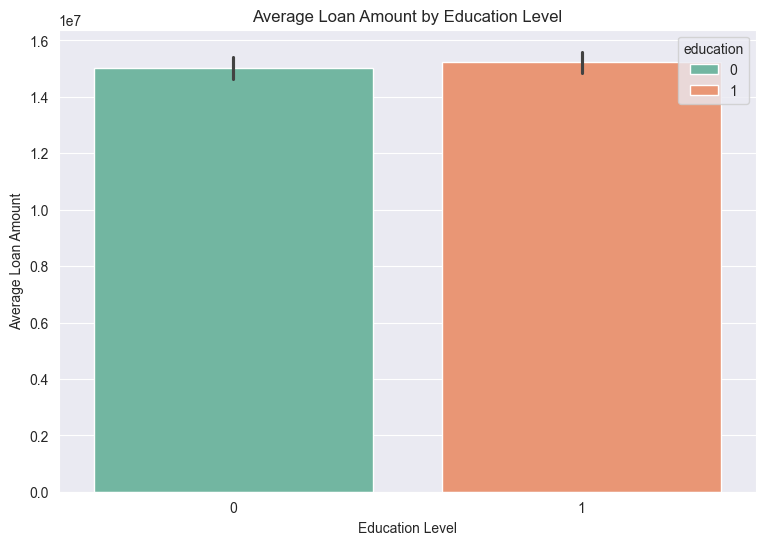

In [20]:
sns.set_style("darkgrid")
plt.figure(figsize=(9,6))
sns.barplot(x='education', y='loan_amount', data=df, palette='Set2', hue='education')

plt.title('Average Loan Amount by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Loan Amount')

plt.xticks(rotation=0)
plt.show()

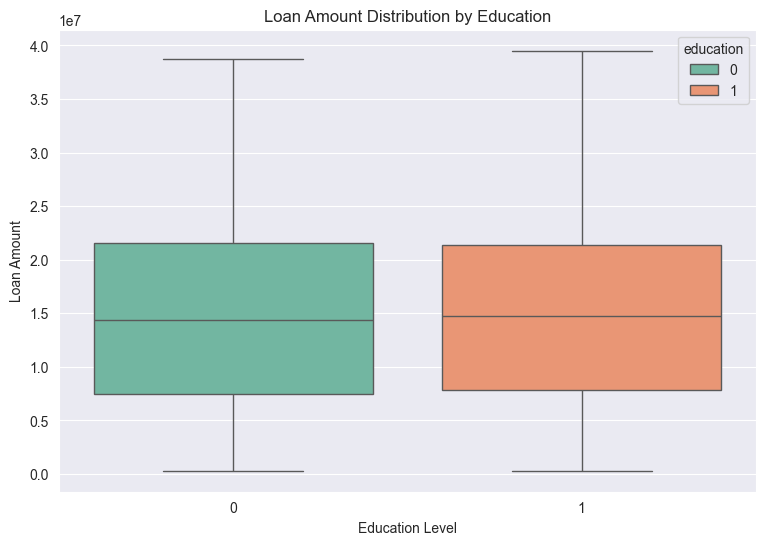

In [23]:
plt.figure(figsize=(9,6))

sns.boxplot(
    data=df,
    x='education', y='loan_amount', palette='Set2', hue='education'
)

plt.title('Loan Amount Distribution by Education')
plt.xlabel('Education Level')
plt.ylabel('Loan Amount')

plt.show()

In [30]:
df_grouped = df.groupby('education')['loan_amount'].mean().reset_index()

fig = px.bar(df_grouped, 
             x='education', 
             y='loan_amount',
             color='education',
             title='Mean Loan Amount by Education Level',
             template='plotly_dark', 
             color_discrete_sequence=px.colors.qualitative.Pastel)


fig.update_layout(
    xaxis_title="Education Status",
    yaxis_title="Mean Loan Amount",
    showlegend=False
)

fig.show()

## 1.3. Dùng kiểm định ANOVA 

In [31]:
import statsmodels.formula.api as smf
import statsmodels.stats.multicomp as multi

In [38]:
model1 = smf.ols(formula='loan_amount ~ C(education)', data=df)

In [39]:
result1 = model1.fit()

In [40]:
print(result1.summary())

                            OLS Regression Results                            
Dep. Variable:            loan_amount   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.4823
Date:                Sun, 03 May 2026   Prob (F-statistic):              0.487
Time:                        23:20:24   Log-Likelihood:                -74436.
No. Observations:                4269   AIC:                         1.489e+05
Df Residuals:                    4267   BIC:                         1.489e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          1.504e+07   1.96e+0

In [32]:
from scipy import stats

In [34]:
group_0 = df[df['education'] == 0]['loan_amount']
group_1 = df[df['education'] == 1]['loan_amount']

In [35]:
f_stat, p_value = stats.f_oneway(group_0, group_1)

print(f"Giá trị F-statistic: {f_stat}")
print(f"Giá trị P-value: {p_value}")

Giá trị F-statistic: 0.48229113790673245
Giá trị P-value: 0.4874241633519155


In [36]:
alpha = 0.05
if p_value < alpha:
    print("Kết luận: Có sự khác biệt có ý nghĩa thống kê về số tiền vay giữa các trình độ học vấn.")
else:
    print("Kết luận: Không có bằng chứng cho thấy trình độ học vấn ảnh hưởng đến số tiền vay.")

Kết luận: Không có bằng chứng cho thấy trình độ học vấn ảnh hưởng đến số tiền vay.


## 1.4. **Kiểm đinh Kruskal-Wallis**

In [42]:
group_not_graduate = df[df['education'] == 0]['loan_amount']
group_graduate = df[df['education'] == 1]['loan_amount']

In [46]:
h_stat, p_value_kw = stats.kruskal(group_not_graduate, group_graduate)

In [47]:
print(f"Giá trị H-statistic: {h_stat:.4f}")
print(f"Giá trị P-value: {p_value_kw:.4f}")

Giá trị H-statistic: 0.3546
Giá trị P-value: 0.5515


In [48]:
alpha = 0.05
if p_value_kw < alpha:
    print("Kết luận: Có sự khác biệt có ý nghĩa thống kê về số tiền vay giữa hai nhóm học vấn.")
else:
    print("Kết luận: Không có bằng chứng cho thấy trình độ học vấn ảnh hưởng đến số tiền vay.")

Kết luận: Không có bằng chứng cho thấy trình độ học vấn ảnh hưởng đến số tiền vay.
